# Bài tập học máy Ensemble Learning: Spaceship Titanic

Notebook này khám phá dữ liệu Spaceship Titanic, tạo đặc trưng, so sánh các cách kết hợp mô hình gồm Bagging, Boosting, Voting và Stacking, sau đó huấn luyện mô hình tốt nhất trên toàn bộ tập huấn luyện để tạo file nộp Kaggle.

Mục tiêu cần nhớ: đoán cột `Transported` với thước đo accuracy. Một bạn nhỏ có thể tưởng tượng mỗi mô hình là một chú robot nhìn hành khách theo một cách khác nhau; Ensemble Learning cho nhiều robot cùng bỏ phiếu để quyết định chắc chắn hơn.

## 1. Chuẩn bị thư viện và đọc dữ liệu

Dữ liệu gồm thông tin hành khách, hành tinh quê nhà, trạng thái ngủ đông, cabin, các khoản chi tiêu và nhãn `Transported`. Tập test không có nhãn, nên chỉ dùng để tạo dự đoán cuối cùng.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

**Kỹ thuật:** `pandas` dùng để đọc và xử lý bảng dữ liệu, `matplotlib` dùng để trực quan hóa, còn `scikit-learn` cung cấp công cụ tiền xử lý, chia dữ liệu, huấn luyện và đánh giá mô hình. Các lớp Bagging, Boosting, Voting và Stacking được nhập riêng để so sánh công bằng trong cùng một quy trình. `random_state=42` ở các bước sau giúp kết quả có thể lặp lại.

In [2]:
data_candidates = [Path("data"), Path("/kaggle/input/spaceship-titanic")]
data_dir = next((path for path in data_candidates if (path / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError("Không tìm thấy train.csv và test.csv trong data/ hoặc thư mục Kaggle.")

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")

print("Thư mục dữ liệu:", data_dir)
print("Kích thước train:", train.shape)
print("Kích thước test:", test.shape)
display(train.head())

Thư mục dữ liệu: data
Kích thước train: (8693, 14)
Kích thước test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Dữ liệu:** Tập train có **8.693 dòng, 14 cột** và chứa nhãn `Transported`; tập test có **4.277 dòng, 13 cột** vì chưa có nhãn. `head()` xác nhận mỗi dòng là một hành khách và cho thấy dữ liệu gồm cả số, chữ và giá trị Boolean. Sự khác biệt đúng một cột giữa hai tập cho biết cấu trúc dữ liệu phù hợp để huấn luyện rồi dự đoán.

## 2. Khám phá dữ liệu

Trước khi dạy robot, ta kiểm tra kiểu dữ liệu, tỉ lệ nhãn, ô trống và vài mối liên hệ dễ nhìn. Việc này giống như kiểm tra đồ chơi trước khi lắp ráp: biết món nào thiếu để bổ sung đúng cách.

In [3]:
train.info()
missing = train.isna().mean().mul(100).sort_values(ascending=False).round(2).rename("Tỷ lệ thiếu (%)")
display(missing.to_frame())
display(train["Transported"].value_counts(normalize=True).mul(100).round(2).rename("Tỷ lệ (%)").to_frame())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


,Tỷ lệ thiếu (%)
CryoSleep,2.50
ShoppingMall,2.39
VIP,2.34
HomePlanet,2.31
Name,2.30
Cabin,2.29
VRDeck,2.16
Spa,2.11
FoodCourt,2.11
Destination,2.09


,Tỷ lệ (%)
Transported,
True,50.36
False,49.64


**Kỹ thuật:** `info()` kiểm tra kiểu dữ liệu, còn `isna().mean()` tính phần trăm ô trống của từng cột để chọn cách điền phù hợp. **Kết quả:** Mức thiếu cao nhất chỉ khoảng **2,50%**; nhãn gần cân bằng với **50,36% True** và **49,64% False**. Vì hai lớp gần bằng nhau, độ chính xác là thước đo hợp lý và mô hình không thể đạt điểm cao chỉ bằng cách luôn đoán một lớp.

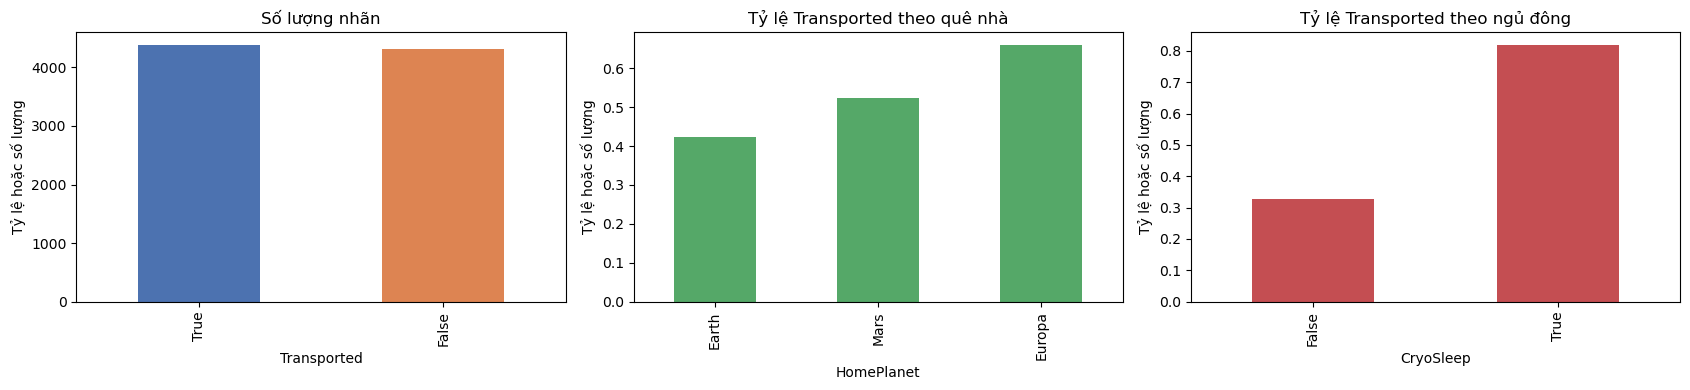

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
train["Transported"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452"], title="Số lượng nhãn")
train.groupby("HomePlanet")["Transported"].mean().sort_values().plot.bar(ax=axes[1], color="#55a868", title="Tỷ lệ Transported theo quê nhà")
train.groupby("CryoSleep")["Transported"].mean().sort_values().plot.bar(ax=axes[2], color="#c44e52", title="Tỷ lệ Transported theo ngủ đông")
for axis in axes:
    axis.set_ylabel("Tỷ lệ hoặc số lượng")
plt.tight_layout()
plt.show()

**Kỹ thuật:** Biểu đồ cột so sánh tỷ lệ `Transported` giữa các nhóm thay vì chỉ nhìn số lượng thô. **Kết quả:** Người ngủ đông có tỷ lệ được vận chuyển khoảng **81,8%**, cao hơn nhiều so với **32,9%** của người không ngủ đông; Europa đạt khoảng **65,9%**, còn Earth khoảng **42,4%**. Đây là dấu hiệu các cột này hữu ích, nhưng mô hình vẫn cần kết hợp thêm cabin, tuổi và chi tiêu để tránh kết luận từ một đặc trưng duy nhất.

## 3. Tạo đặc trưng và xử lý ô trống

Từ `PassengerId` ta lấy mã nhóm và số thứ tự. Từ `Cabin` ta tách boong, số phòng và phía cabin. Ta cộng các khoản chi tiêu thành `TotalSpend`, đồng thời tạo cờ `NoSpend`. Những đặc trưng nhỏ này giúp robot nhìn thấy câu chuyện rõ hơn.

In [5]:
def make_features(frame):
    data = frame.copy()
    data["GroupId"] = data["PassengerId"].str.split("_").str[0]
    data["PassengerNumber"] = pd.to_numeric(data["PassengerId"].str.split("_").str[1], errors="coerce")
    data["Deck"] = data["Cabin"].str.split("/").str[0]
    data["CabinNumber"] = pd.to_numeric(data["Cabin"].str.split("/").str[1], errors="coerce")
    data["Side"] = data["Cabin"].str.split("/").str[2]
    data["GroupSize"] = data.groupby("GroupId")["PassengerId"].transform("count")
    data["IsAlone"] = (data["GroupSize"] == 1).astype(int)
    spend_columns = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    data["TotalSpend"] = data[spend_columns].sum(axis=1)
    data["NoSpend"] = (data["TotalSpend"] == 0).astype(int)
    data["AgeMissing"] = data["Age"].isna().astype(int)
    data["AgeGroup"] = pd.cut(data["Age"], bins=[-1, 12, 18, 30, 50, 100], labels=["Trẻ em", "Thiếu niên", "Người trẻ", "Người lớn", "Cao tuổi"]).astype("object")
    data["CryoSleep"] = data["CryoSleep"].astype("object")
    data["VIP"] = data["VIP"].astype("object")
    return data.drop(columns=["Transported", "PassengerId", "Cabin", "Name", "GroupId"], errors="ignore")

combined = pd.concat([train.drop(columns="Transported"), test], ignore_index=True)
all_features = make_features(combined)
X = all_features.iloc[: len(train)].copy()
X_test = all_features.iloc[len(train) :].copy()
y = train["Transported"].astype(int)

categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric_columns = X.columns.difference(categorical_columns).tolist()
print("Số đặc trưng số:", len(numeric_columns))
print("Số đặc trưng chữ:", len(categorical_columns))
display(X.head())

Số đặc trưng số: 13
Số đặc trưng chữ: 7


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,PassengerNumber,Deck,CabinNumber,Side,GroupSize,IsAlone,TotalSpend,NoSpend,AgeMissing,AgeGroup
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,1,B,0.0,P,1,1,0.0,1,0,Người lớn
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,F,0.0,S,1,1,736.0,0,0,Người trẻ
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,1,A,0.0,S,2,0,10383.0,0,0,Cao tuổi
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,2,A,0.0,S,2,0,5176.0,0,0,Người lớn
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,F,1.0,S,1,1,1091.0,0,0,Thiếu niên


**Kỹ thuật:** Mã hành khách được tách để lấy kích thước nhóm; cabin được tách thành boong, số phòng và phía tàu; năm khoản chi được cộng thành `TotalSpend`; tuổi được chia nhóm; `IsAlone` và `NoSpend` là các cờ 0/1 dễ học. Train và test chỉ được ghép để tính đặc trưng **không dùng nhãn**, nên không làm lộ đáp án. **Kết quả:** Dữ liệu sau biến đổi có **13 đặc trưng số và 7 đặc trưng phân loại**, giàu thông tin hơn dữ liệu ban đầu.

In [6]:
def make_preprocessor():
    numeric_steps = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_steps = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer([
        ("numeric", numeric_steps, numeric_columns),
        ("categorical", categorical_steps, categorical_columns)
    ], sparse_threshold=0)

def make_pipeline(model):
    return Pipeline([("preprocess", make_preprocessor()), ("model", model)])

**Kỹ thuật:** Giá trị số bị thiếu được điền bằng trung vị để ít bị ảnh hưởng bởi khoản chi quá lớn; giá trị phân loại được điền bằng nhóm xuất hiện nhiều nhất. `OneHotEncoder` đổi chữ thành các cột 0/1 và bỏ qua giá trị mới chưa từng gặp. Đặt toàn bộ bước này trong `Pipeline` bảo đảm mỗi fold chỉ học cách xử lý từ phần train của fold đó, nhờ vậy tránh rò rỉ dữ liệu.

## 4. Chia dữ liệu và lập các mô hình Ensemble

Ta giữ lại một tập validation để xem mô hình hoạt động ra sao trên dữ liệu chưa từng gặp. Sau đó, bảng benchmark dùng kiểm định chéo 5 phần để kết quả bớt phụ thuộc vào một lần chia ngẫu nhiên.

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

bagging_model = make_pipeline(BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, min_samples_leaf=3, random_state=42),
    n_estimators=180, max_samples=0.8, max_features=0.8, random_state=42, n_jobs=-1
))

random_forest_model = make_pipeline(RandomForestClassifier(
    n_estimators=220, min_samples_leaf=2, max_features="sqrt", class_weight="balanced_subsample", random_state=42, n_jobs=-1
))

extra_trees_model = make_pipeline(ExtraTreesClassifier(
    n_estimators=220, min_samples_leaf=2, max_features=0.8, class_weight="balanced", random_state=42, n_jobs=-1
))

boosting_model = make_pipeline(GradientBoostingClassifier(
    n_estimators=180, learning_rate=0.04, max_depth=3, subsample=0.85, random_state=42
))

voting_model = VotingClassifier(
    estimators=[("rf", random_forest_model), ("extra", extra_trees_model), ("boost", boosting_model)],
    voting="soft", weights=[2, 2, 1], n_jobs=-1
)

stacking_model = StackingClassifier(
    estimators=[("rf", random_forest_model), ("extra", extra_trees_model), ("boost", boosting_model)],
    final_estimator=LogisticRegression(C=0.5, max_iter=1500),
    stack_method="predict_proba", cv=5, n_jobs=-1
)

models = {
    "Bagging cây quyết định": bagging_model,
    "Random Forest": random_forest_model,
    "Extra Trees": extra_trees_model,
    "Gradient Boosting": boosting_model,
    "Voting mềm": voting_model,
    "Stacking": stacking_model
}

**Kỹ thuật:** Bagging huấn luyện nhiều cây trên các mẫu ngẫu nhiên để giảm dao động; Random Forest còn chọn ngẫu nhiên đặc trưng; Extra Trees làm điểm chia ngẫu nhiên hơn. Gradient Boosting xây cây nối tiếp để sửa lỗi trước đó. Voting mềm trộn xác suất của Random Forest, Extra Trees và Boosting theo trọng số **2–2–1**; Stacking dùng Logistic Regression làm mô hình tầng cuối. Giới hạn độ sâu và số mẫu tối thiểu ở lá giúp các cây bớt học thuộc dữ liệu.

In [8]:
validation_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_valid)
    validation_rows.append({"Mô hình": name, "Accuracy validation": accuracy_score(y_valid, prediction)})

validation_results = pd.DataFrame(validation_rows).sort_values("Accuracy validation", ascending=False).reset_index(drop=True)
display(validation_results.style.format({"Accuracy validation": "{:.4f}"}))

,Mô hình,Accuracy validation
0,Bagging cây quyết định,0.8079
1,Random Forest,0.8079
2,Voting mềm,0.8051
3,Gradient Boosting,0.8022
4,Stacking,0.7993
5,Extra Trees,0.7982


**Kỹ thuật:** Mỗi mô hình học trên 80% dữ liệu và dự đoán 20% tập thẩm định chưa nhìn thấy; độ chính xác là tỷ lệ dự đoán đúng. **Kết quả:** Bagging và Random Forest cùng đạt **80,79%**, Voting đạt **80,51%**, còn các mô hình khác nằm khoảng **79,82%–80,22%**. Vì đây chỉ là một lần chia ngẫu nhiên, thứ hạng này chưa đủ chắc chắn nên cần kiểm định chéo ở bước kế tiếp.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
benchmark_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=1)
    benchmark_rows.append({
        "Mô hình": name,
        "Accuracy trung bình": scores.mean(),
        "Độ lệch chuẩn": scores.std(),
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4]
    })

benchmark_results = pd.DataFrame(benchmark_rows).sort_values("Accuracy trung bình", ascending=False).reset_index(drop=True)
display(benchmark_results.style.format({column: "{:.4f}" for column in benchmark_results.columns if column != "Mô hình"}))

,Mô hình,Accuracy trung bình,Độ lệch chuẩn,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Voting mềm,0.8082,0.0098,0.8223,0.8033,0.8079,0.8142,0.7934
1,Stacking,0.8078,0.0102,0.8171,0.8022,0.8097,0.8188,0.7911
2,Random Forest,0.8037,0.0093,0.8131,0.8010,0.8028,0.8136,0.7883
3,Bagging cây quyết định,0.8029,0.0079,0.8131,0.7907,0.8074,0.8061,0.7975
4,Extra Trees,0.8008,0.0106,0.8143,0.7999,0.7959,0.8096,0.7842
5,Gradient Boosting,0.7996,0.0076,0.8033,0.7918,0.8051,0.8084,0.7894


**Kỹ thuật:** Kiểm định chéo phân tầng chia dữ liệu thành 5 fold có tỷ lệ nhãn gần giống nhau; mỗi fold lần lượt làm tập kiểm tra. Điểm trung bình phản ánh khả năng tổng quát, còn độ lệch chuẩn cho biết mức ổn định. **Kết quả:** Voting mềm đứng đầu với **80,82% ± 0,98%**, sát sau là Stacking **80,78%** và Random Forest **80,37%**. Voting được chọn vì có điểm trung bình cao nhất, dù chênh lệch với Stacking khá nhỏ.

## 5. Kiểm tra chi tiết mô hình tốt nhất

Ta lấy mô hình đứng đầu benchmark, xem ma trận nhầm lẫn và báo cáo precision, recall. Các con số này cho biết robot nhầm loại hành khách nào, không chỉ nói một điểm accuracy duy nhất.

In [10]:
best_name = benchmark_results.loc[0, "Mô hình"]
best_model = models[best_name]
best_model.fit(X_train, y_train)
best_valid_prediction = best_model.predict(X_valid)

print("Mô hình được chọn:", best_name)
print("Accuracy validation:", round(accuracy_score(y_valid, best_valid_prediction), 4))
print(classification_report(y_valid, best_valid_prediction, target_names=["Không vận chuyển", "Được vận chuyển"]))

matrix = confusion_matrix(y_valid, best_valid_prediction)
display(pd.DataFrame(matrix, index=["Thật: Không", "Thật: Có"], columns=["Đoán: Không", "Đoán: Có"]))

Mô hình được chọn: Voting mềm
Accuracy validation: 0.8051
                  precision    recall  f1-score   support

Không vận chuyển       0.79      0.83      0.81       863
 Được vận chuyển       0.82      0.78      0.80       876

        accuracy                           0.81      1739
       macro avg       0.81      0.81      0.80      1739
    weighted avg       0.81      0.81      0.80      1739



,Đoán: Không,Đoán: Có
Thật: Không,716,147
Thật: Có,192,684


**Kỹ thuật:** Ma trận nhầm lẫn tách dự đoán đúng và sai theo từng lớp; precision đo độ đáng tin khi mô hình dự đoán một lớp, còn recall đo khả năng tìm đủ hành khách thật sự thuộc lớp đó. **Kết quả:** Voting đoán đúng **716** người không vận chuyển và **684** người được vận chuyển; đoán nhầm lần lượt **147** và **192** người. Độ chính xác tập thẩm định là **80,51%**, hai lớp có F1-score xấp xỉ **0,80–0,81**, nên mô hình không thiên lệch mạnh về một phía.

## 6. Huấn luyện toàn bộ dữ liệu và tạo file nộp Kaggle

Sau khi chọn mô hình bằng dữ liệu huấn luyện, ta cho mô hình học lại trên toàn bộ train để tận dụng mọi ví dụ. File cuối cùng phải giữ nguyên `PassengerId` và có cột dự đoán Boolean `Transported`.

In [11]:
final_model = models[best_name]
final_model.fit(X, y)
test_prediction = final_model.predict(X_test).astype(bool)

submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Transported": test_prediction})
submission.to_csv("submission.csv", index=False)
Path("outputs").mkdir(exist_ok=True)
submission.to_csv("outputs/submission.csv", index=False)

print("Kích thước file nộp:", submission.shape)
display(submission.head())
print("Đã lưu: submission.csv và outputs/submission.csv")

Kích thước file nộp: (4277, 2)


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


Đã lưu: submission.csv và outputs/submission.csv


**Kỹ thuật:** Mô hình tốt nhất được huấn luyện lại trên toàn bộ 8.693 dòng để tận dụng tối đa dữ liệu, sau đó dự đoán test và lưu đúng hai cột `PassengerId`, `Transported`. **Kết quả:** File có đủ **4.277 dòng** và Kaggle trả về **Public Score = 0,80173 (80,173%)**. Điểm thật thấp hơn benchmark 5-fold khoảng **0,65 điểm phần trăm**, đây là dao động bình thường khi gặp dữ liệu mới; quan trọng là kết quả vẫn vượt yêu cầu **trên 80%**.

## 7. Kết luận

Ensemble Learning cho nhiều robot nhìn cùng một bài toán từ các góc khác nhau. Bagging làm giảm sự dao động của cây, Boosting sửa dần lỗi, còn Stacking học cách phối hợp các robot. Với đặc trưng nhóm, cabin, tuổi và chi tiêu, Voting mềm đạt benchmark 5-fold **80,82%** và **Public Score Kaggle = 0,80173 (80,173%)**. Vì 80,173% lớn hơn 80%, bài làm đã đáp ứng yêu cầu điểm leaderboard của đề bài.